In [1]:
# Import Libraries
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import lasio

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [2]:
# Input and output paths
ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
PROCESSED.mkdir(parents=True, exist_ok=True)

## Loading and Visualizing LAS

In [3]:
# Check the wells and logs available in the LAS files
well_names = ["BLT-01", "JUT-01", "EVD-01", "PKP-01"]
dfs_las = {}

for well in well_names:
    las = lasio.read(RAW / f"{well}.las")
    df_las = las.df().reset_index()

    dfs_las[well] = df_las

    print(f"\nWell Name: {well}")
    print("LAS DataFrame shape:", df_las.shape)
    print("Columns:", list(df_las.columns))
    df_las.head(8)


Well Name: BLT-01
LAS DataFrame shape: (27875, 20)
Columns: ['MD', 'BITSIZE', 'CALI', 'CASING_FLAG-(S)GR_NPHI_DTC', 'DRHO', 'DTC', 'DTS', 'DTST', 'GR', 'GRKT', 'GRTO', 'NPHI', 'PE', 'POTA', 'RD', 'RHOB', 'RM', 'RS', 'THOR', 'URAN']

Well Name: JUT-01
LAS DataFrame shape: (22427, 5)
Columns: ['DEPT:1', 'DEPT:2', 'GR', 'DT', 'RHOB']

Well Name: EVD-01
LAS DataFrame shape: (21569, 5)
Columns: ['DEPT', 'GR', 'DT', 'RHOB', 'DRHO']

Well Name: PKP-01
LAS DataFrame shape: (27508, 6)
Columns: ['DEPT', 'GR', 'DT', 'RHOB', 'DRHO', 'NPHI']


In [4]:
# Choose depth column in metres
depth_cols = ["MD", "DEPT:1", "DEPT:2", "DEPT"]

for well in well_names:
    las = lasio.read(f"{RAW}/{well}.las")
    md_m = None
    for c in depth_cols:
        
        if c not in dfs_las[well].columns:
            continue

        unit = None
        for curve in las.curves:
            if curve.mnemonic == c:
                unit = (curve.unit or "").upper()
                break

        if unit in ("M", "M "):
            md_m = dfs_las[well][c].values
            break

    if md_m is None:
        print(f"No metric depth found for {well}")
        continue

    dfs_las[well]["MD_m"] = md_m
    
    # Standardise sonic log column
    for col in ["DT", "DTC"]:
        if col in dfs_las[well].columns:
            dfs_las[well] = dfs_las[well].rename(columns={col: "DTC"})
            break

    dfs_las[well] = dfs_las[well].set_index("MD_m")

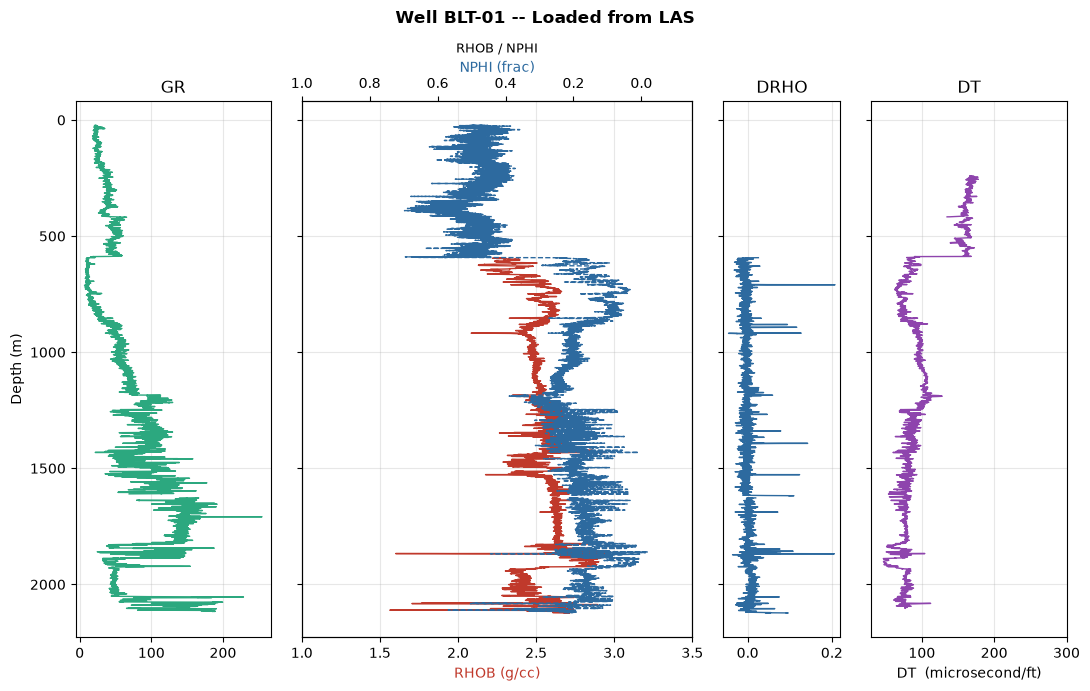

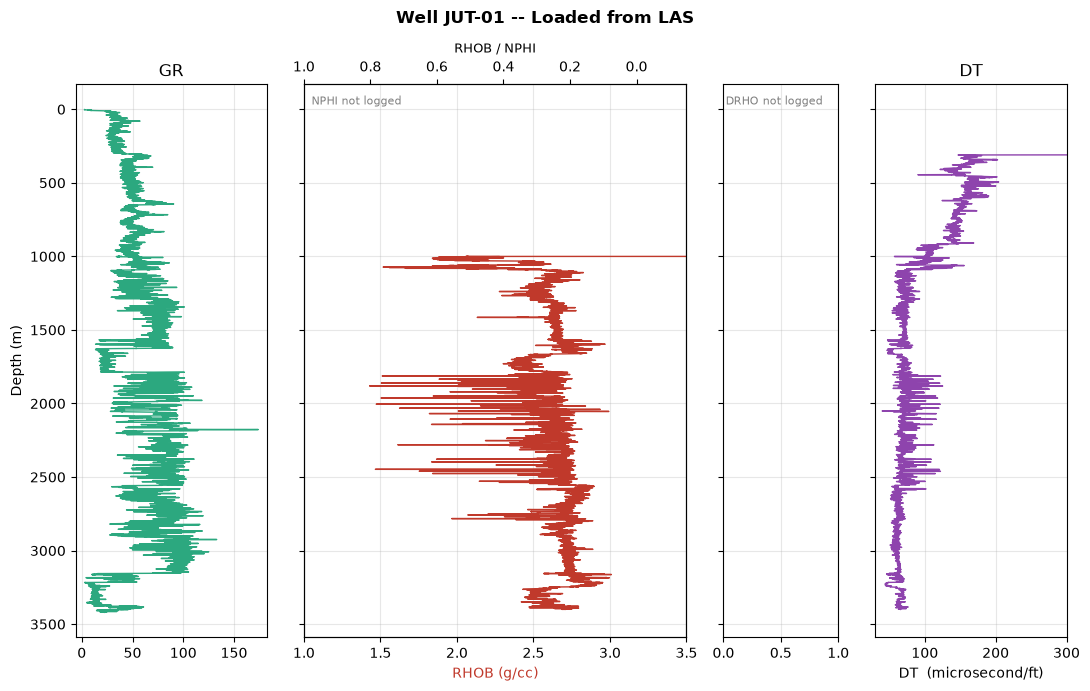

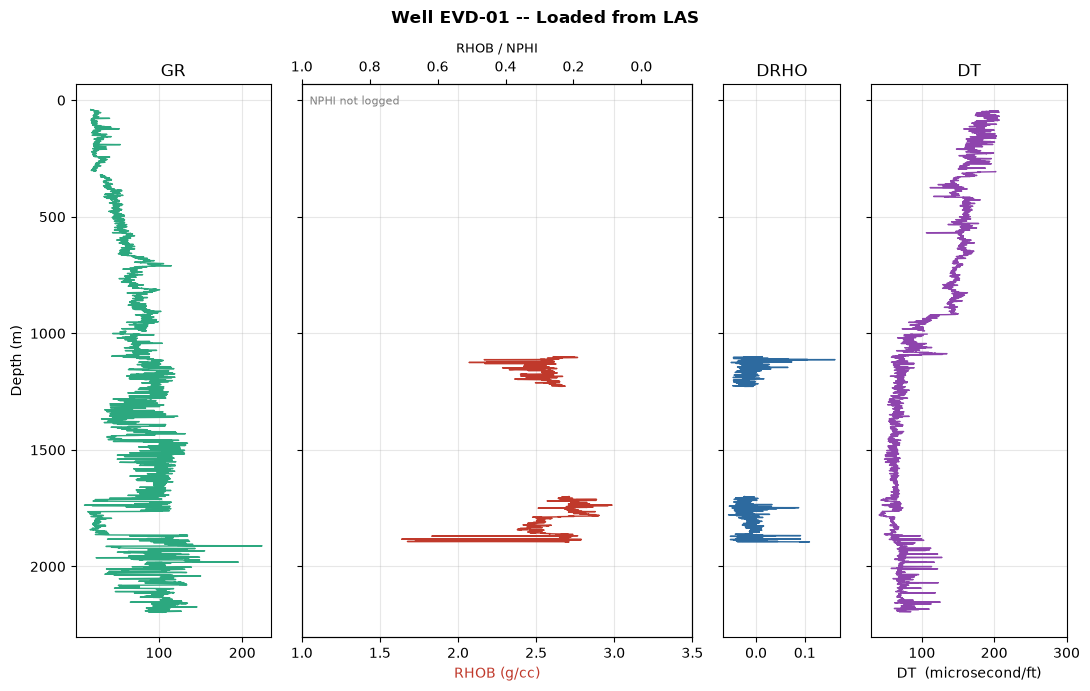

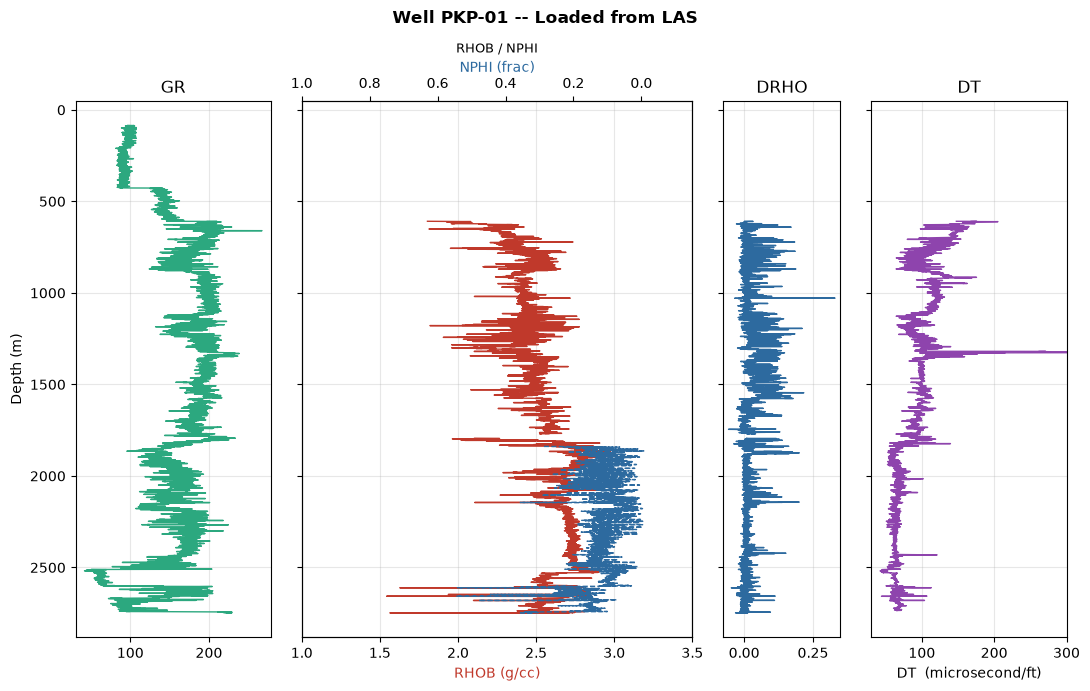

In [5]:
# GR, RHOB, NPHI, DRHO, DTC logs plotted
for well in well_names:
    df_las = dfs_las[well]

    depth_col = "MD_m"
    df_las_clean = df_las.reset_index().sort_values(depth_col)
    dfs_las[well] = df_las_clean

    fig, axes = plt.subplots(1, 4, figsize=(11, 7), sharey=True, gridspec_kw={"width_ratios": [1, 2, 0.6, 1]})
    fig.suptitle(f"Well {well} -- Loaded from LAS", fontsize=12, fontweight="bold")

    axes[0].plot(df_las_clean["GR"], df_las_clean[depth_col], color="#2ca87f", linewidth=1)
    axes[0].set_label("GR (API)") 
    axes[0].set_title("GR") 
    axes[0].invert_yaxis() 
    axes[0].set_ylabel("Depth (m)") 

    ax2a = axes[1]
    ax2b = ax2a.twiny()
    ax2a.plot(df_las_clean["RHOB"], df_las_clean[depth_col], color="#c0392b", linewidth=1, label="RHOB")
    ax2a.set_xlabel("RHOB (g/cc)", color="#c0392b")

    if "NPHI" in df_las_clean.columns:
        ax2b.plot(df_las_clean["NPHI"], df_las_clean[depth_col], color="#2d6a9f", linewidth=1, linestyle="--", label="NPHI")
        ax2b.set_xlabel("NPHI (frac)", color="#2d6a9f")
    else:
        ax2a.text(0.02, 0.98, "NPHI not logged", transform=ax2a.transAxes, va="top", fontsize=8, color="gray")
    axes[1].set_title("RHOB / NPHI", fontsize=9) 
    ax2a.set_xlim(1.0, 3.5)
    ax2b.set_xlim(1.0, -0.15)

    if "DRHO" in df_las_clean.columns:
        axes[2].plot(df_las_clean["DRHO"], df_las_clean[depth_col], color="#2d6a9f", linewidth=1)
        axes[2].set_label("DRHO  (g/cc)")
        axes[2].set_title("DRHO")
    else:
        axes[2].text(0.02, 0.98, "DRHO not logged", transform=axes[2].transAxes, va="top", fontsize=8, color="gray")

    if "DTC" in df_las_clean.columns:
        axes[3].plot(df_las_clean["DTC"], df_las_clean[depth_col], color="#8e44ad", linewidth=1)
        axes[3].set_xlabel("DT  (microsecond/ft)")
        axes[3].set_title("DT")
        axes[3].set_xlim(30, 300)

    for ax in axes: 
        ax.grid(True, alpha=0.3)

    plt.tight_layout() 
    plt.show()

## Loading CSV

In [6]:
# Load raw target lithologies data
raw_data = pd.read_csv(RAW / "target_lithologies.csv")
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3455 entries, 0 to 3454
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                3455 non-null   str    
 1   easting                3455 non-null   float64
 2   northing               3455 non-null   float64
 3   depth_tvd_m            0 non-null      float64
 4   porosity_pct           2419 non-null   float64
 5   gamma_ray_api          3455 non-null   float64
 6   bulk_density_gcc       3199 non-null   float64
 7   formation_top_tvd      3455 non-null   float64
 8   formation_base_tvd     3455 non-null   float64
 9   formation_thickness_m  3455 non-null   float64
 10  distance_to_usp_km     3455 non-null   float64
 11  flag                   3455 non-null   str    
 12  flag_reason            3455 non-null   str    
dtypes: float64(10), str(3)
memory usage: 351.0 KB


## Checking 'well_id'

In [7]:
df = raw_data.copy() 
df['well_id'].value_counts()

well_id
BLT-01    1689
EVD-01     780
PKP-01     730
JUT-01     256
Name: count, dtype: int64

## Checking empty rows

In [8]:
# 'depth_tvd_m'
missing_rows = df[df['depth_tvd_m'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing depth_tvd_m counts per well:")
    print(missing_rows)

# 'porosity_pct'
missing_rows = df[df['porosity_pct'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing porosity_pct counts per well:")
    print(missing_rows)

# 'bulk_density_gcc'
missing_rows = df[df['bulk_density_gcc'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing bulk_density_gcc counts per well:")
    print(missing_rows)


Missing depth_tvd_m counts per well:
well_id
BLT-01    1689
EVD-01     780
JUT-01     256
PKP-01     730
dtype: int64

Missing porosity_pct counts per well:
well_id
EVD-01    780
JUT-01    256
dtype: int64

Missing bulk_density_gcc counts per well:
well_id
JUT-01    256
dtype: int64


### Filling in 'depth_tvd_m'

In [9]:
# Load Well Path Data
wp = {}

for well in well_names:
    wp[well] = pd.read_excel(RAW / "Well Path Data.xlsx", sheet_name=well)

    wp[well] = wp[well].rename(columns={
        "Depth (m)": "MD_m", "TVD (m)": "TVD_m",
        "Inclination (º)": "incl_deg", "Azimuth (º)": "azim_deg",
        "X-offset (m)": "x_offset_m", "Y-offset (m)": "y_offset_m"
    })

In [10]:
def recover_depth(well, target_rows, las_curves, well_path):
    top_depth = target_rows["formation_top_tvd"].iloc[0]
    bottom_depth = target_rows["formation_base_tvd"].iloc[0]

    gr = las_curves.dropna(subset=["GR", "MD_m"]).reset_index(drop=True)
    gr = gr[(gr["MD_m"] >= top_depth) & (gr["MD_m"] <= bottom_depth)].copy()

    survey_md = well_path["MD_m"].values
    survey_tvd = well_path["TVD_m"].values
    gr["depth_tvd_m"] = np.interp(gr["MD_m"], survey_md, survey_tvd)

    target_clean = target_rows.reset_index().drop(columns=["depth_tvd_m"])
    merged = target_clean.merge(
        gr[["GR", "depth_tvd_m"]].rename(columns={"GR": "gamma_ray_api"}),
        on="gamma_ray_api", how="left"
    ).drop_duplicates(subset="index").set_index("index")

    n_matched = merged["depth_tvd_m"].notna().sum()
    print(f"{well}: {n_matched} / {len(target_rows)} rows matched")
    df.loc[merged.index, "depth_tvd_m"] = merged["depth_tvd_m"]

In [11]:
def rebuild_jut01_rows(target_rows, las_curves, well_path):
    global df
    top_depth = target_rows["formation_top_tvd"].iloc[0]
    bottom_depth = target_rows["formation_base_tvd"].iloc[0]

    gr = las_curves.dropna(subset=["GR", "RHOB", "MD_m"]).reset_index(drop=True)
    gr = gr[(gr["MD_m"] >= top_depth) & (gr["MD_m"] <= bottom_depth)].copy()

    survey_md = well_path["MD_m"].values
    survey_tvd = well_path["TVD_m"].values
    gr["depth_tvd_m"] = np.interp(gr["MD_m"], survey_md, survey_tvd)

    new_rows = pd.DataFrame({
        "well_id": "JUT-01",
        "depth_tvd_m":        gr["depth_tvd_m"],
        "gamma_ray_api":      gr["GR"],
        "bulk_density_gcc":   gr["RHOB"],
        "formation_top_tvd":  top_depth,
        "formation_base_tvd": bottom_depth,
        "formation_thickness_m": 127.5,
    })
    for col in ["easting", "northing", "distance_to_usp_km"]:
        if col in target_rows.columns:
            new_rows[col] = target_rows[col].iloc[0]

    df = df[df["well_id"] != "JUT-01"]
    df = pd.concat([df, new_rows], ignore_index=True)
    print(f"JUT-01: replaced {len(target_rows)} wrong-window rows with {len(new_rows)} correct rows")

In [12]:
for well in well_names:
    target_rows = df[df["well_id"] == well]
    if well == "JUT-01":
        rebuild_jut01_rows(target_rows, dfs_las[well], wp[well])
    else:    
        recover_depth(well, target_rows, dfs_las[well], wp[well])

BLT-01: 1689 / 1689 rows matched
JUT-01: replaced 256 wrong-window rows with 836 correct rows
EVD-01: 780 / 780 rows matched
PKP-01: 730 / 730 rows matched


In [13]:
well_list = df['well_id'].unique().tolist()
print(f"\nThis  is a list of all the wells in target_lithologies.csv: {well_list}")
log_cols = ["porosity_pct", "gamma_ray_api", "bulk_density_gcc"]
print(f"\nThese are the log columns in target_lithologies.csv: {log_cols}")


This  is a list of all the wells in target_lithologies.csv: ['EVD-01', 'PKP-01', 'BLT-01', 'JUT-01']

These are the log columns in target_lithologies.csv: ['porosity_pct', 'gamma_ray_api', 'bulk_density_gcc']


## Log and Target CSV Overlay

C:\Users\sadar\AppData\Local\Temp\ipykernel_29224\3727583388.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\sadar\AppData\Local\Temp\ipykernel_29224\3727583388.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


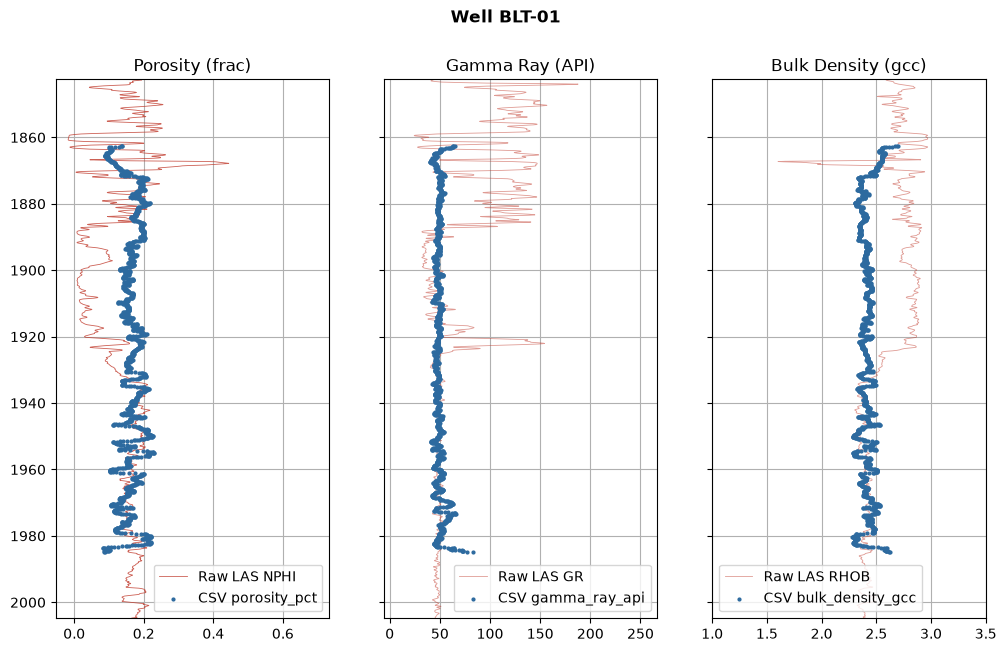

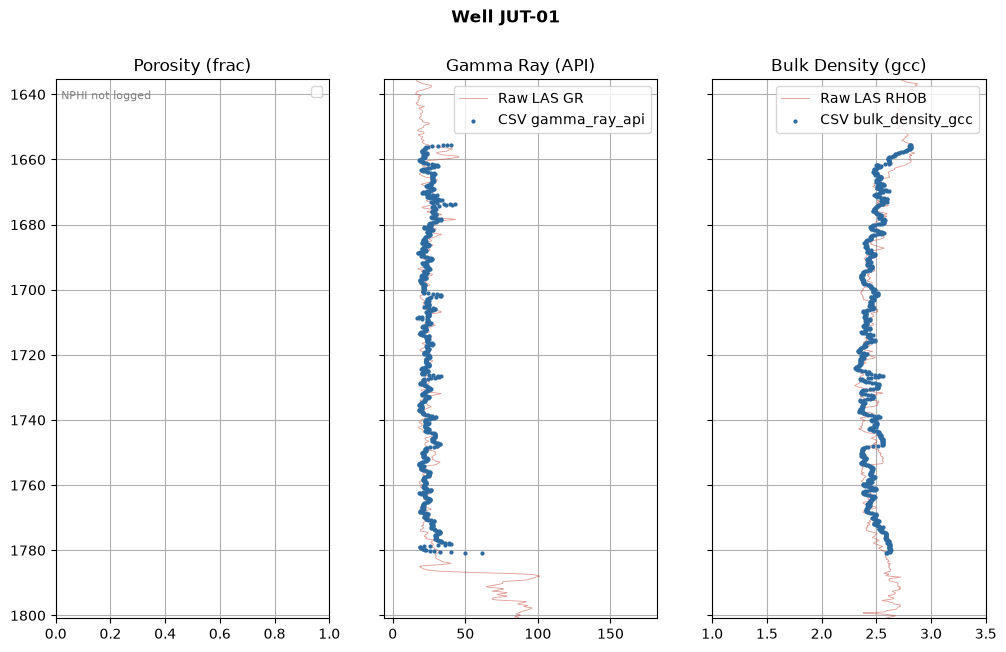

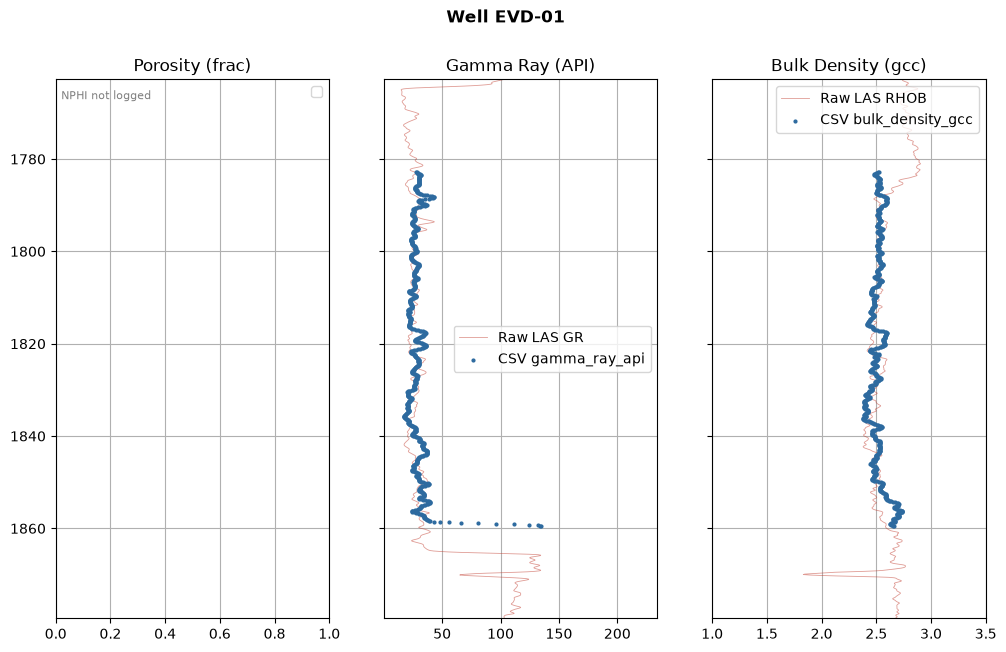

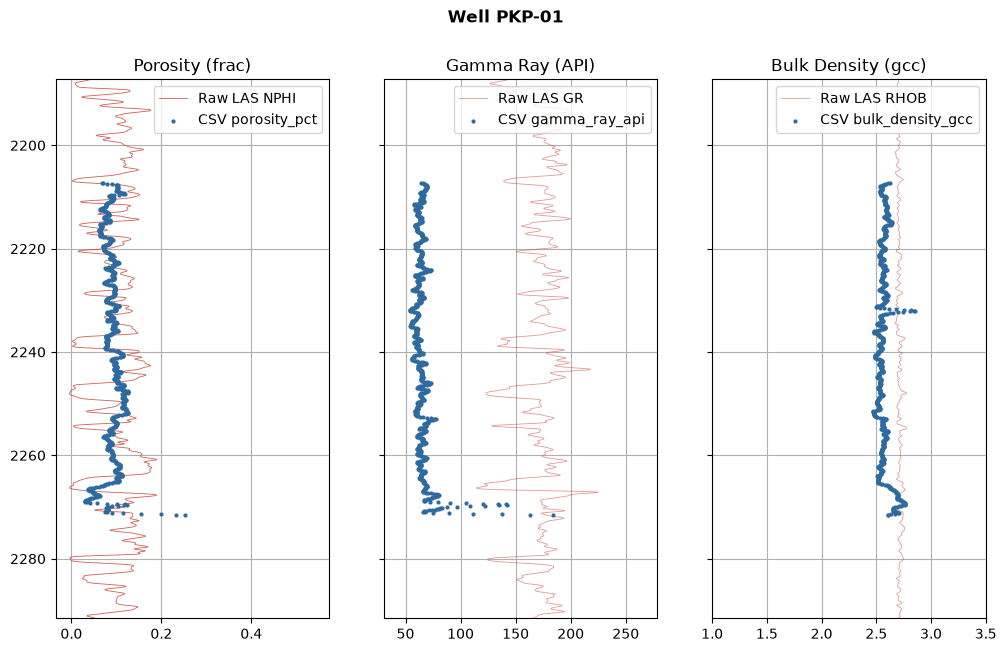

In [14]:
for well in well_names:
    well_log = dfs_las[well]
    csv_rows =df[df["well_id"] == well].reset_index()

    depth_col = "MD_m"

    has_nphi = "NPHI" in well_log.columns

    fig, axes = plt.subplots(1, 3, figsize=(12, 7), sharey = True)
    fig.suptitle(f"Well {well}", fontsize=12, fontweight="bold")
    if has_nphi:
        axes[0].plot(well_log["NPHI"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.8, label="Raw LAS NPHI")
        axes[0].scatter(csv_rows["porosity_pct"]/100, csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV porosity_pct")
    else:
        axes[0].text(0.02, 0.98, "NPHI not logged", transform=axes[0].transAxes, va="top", fontsize=8, color="gray")
    axes[0].set_title("Porosity (frac)")

    axes[1].plot(well_log["GR"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.5, label="Raw LAS GR")
    axes[1].scatter(csv_rows["gamma_ray_api"], csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV gamma_ray_api")
    axes[1].set_title("Gamma Ray (API)")

    axes[2].plot(well_log["RHOB"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.5, label="Raw LAS RHOB")
    axes[2].scatter(csv_rows["bulk_density_gcc"], csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV bulk_density_gcc")
    axes[2].set_xlim(1.0, 3.5)
    axes[2].set_title("Bulk Density (gcc)")

    for ax in axes:
        ax.set_ylim(csv_rows["depth_tvd_m"].max() + 20, csv_rows["depth_tvd_m"].min() - 20)
        ax.grid()
        ax.legend()

## Checking empty rows

In [15]:
# 'depth_tvd_m'
missing_rows = df[df['depth_tvd_m'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing depth_tvd_m rows') 
else:
    print("\nMissing depth_tvd_m counts per well:")
    print(missing_rows)

# 'porosity_pct'
missing_rows = df[df['porosity_pct'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing porosity_pct rows') 
else:
    print("\nMissing porosity_pct counts per well:")
    print(missing_rows)

# 'bulk_density_gcc'
missing_rows = df[df['bulk_density_gcc'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing bulk_density_gcc rows') 
else:
    print("\nMissing bulk_density_gcc counts per well:")
    print(missing_rows)


No missing depth_tvd_m rows

Missing porosity_pct counts per well:
well_id
EVD-01    780
JUT-01    836
dtype: int64

No missing bulk_density_gcc rows


## Filling in 'porosity_pct'

### Classic 'Bulk Density' vs 'Porosity' Relationship

Well PKP-01 correlation coefficient: -0.472
Well BLT-01 correlation coefficient: -0.949


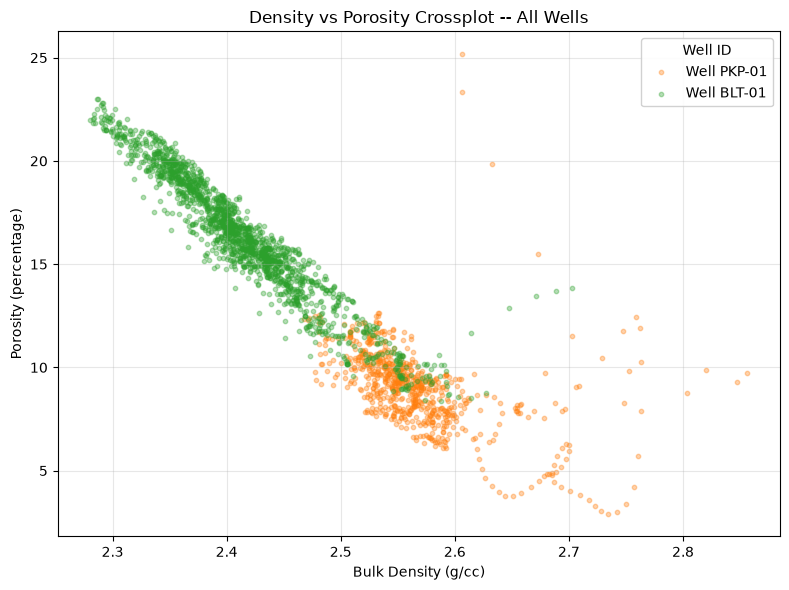

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = cm.tab10.colors

for i, well_id in enumerate(well_list):
    well_df = df[df["well_id"] == well_id]
    if well_df["bulk_density_gcc"].notna().any() and well_df["porosity_pct"].notna().any():
        ax.scatter(
            well_df["bulk_density_gcc"],
            well_df["porosity_pct"],
            alpha=0.35,
            s=10,
            color=colors[i % len(colors)],
            label=f"Well {well_id}"
        )
        corr = well_df["bulk_density_gcc"].corr(well_df["porosity_pct"])
        print(f"Well {well_id} correlation coefficient: {round(corr, 3)}")

ax.set_xlabel("Bulk Density (g/cc)")
ax.set_ylabel("Porosity (percentage)")
ax.set_title("Density vs Porosity Crossplot -- All Wells")
ax.grid(True, alpha=0.3)
ax.legend(title="Well ID", loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

$$\text{Porosity - Density Equation}$$
$$\phi = \frac{\rho_{ma} - \rho_b}{\rho_{ma} - \rho_{fl}} \times 100$$

In [17]:
# Slochteren Sandstone constants
# 2.65 g/cc -quartz sandstone matrix density(2.65, 2.68)
# 1.07 g/cc -saline formation brine density(1.07, 1.1)

RHO_MA = 2.69 
RHO_FL = 1.0

df['rhob_porosity_pct'] = (
    ((RHO_MA - df['bulk_density_gcc']) / (RHO_MA - RHO_FL))
    .clip(0.02, 1.0) 
    * 100
)

$$\text{Wyllie Time-Average Equation}$$
$$\phi_{\text{sonic}} = \frac{DT_{\text{log}} - DT_{\text{ma}}}{DT_{\text{fl}} - DT_{\text{ma}}} \times 100$$

In [18]:
# Transfer DT log from las to target_lithologies -- merge on GR value (not position),
# since GR and DT come from the same LAS rows and GR is already correctly matched.
df["transit_time"] = np.nan

for well in well_list:
    las = dfs_las[well]  # already has MD_m and standardized DTC column from cells 3-5
    depth_col = "MD_m"
    dt_col = "DTC"

    mask = df["well_id"] == well
    formation_top = df.loc[mask, "formation_top_tvd"].iloc[0]
    formation_base = df.loc[mask, "formation_base_tvd"].iloc[0]

    subset = las[(las[depth_col] >= formation_top) & (las[depth_col] <= formation_base)]
    subset = subset.dropna(subset=["GR", dt_col])

    merged = df[mask].reset_index().merge(
        subset[["GR", dt_col]].rename(columns={"GR": "gamma_ray_api", dt_col: "transit_time_new"}),
        on="gamma_ray_api", how="left"
    ).drop_duplicates(subset="index").set_index("index")

    n_matched = merged["transit_time_new"].notna().sum()
    print(f"{well}: {n_matched} / {mask.sum()} transit_time rows matched")

    df.loc[merged.index, "transit_time"] = merged["transit_time_new"]

EVD-01: 780 / 780 transit_time rows matched
PKP-01: 730 / 730 transit_time rows matched
BLT-01: 1689 / 1689 transit_time rows matched
JUT-01: 836 / 836 transit_time rows matched


In [19]:
# Slochteren Sandstone constants
# 55.5 mu.s/ft -quartz sandstone matrix(55.5)
# 185 mu.s/ft -saline formation brine (185, 190)

DT_MA = 55.5 
DT_FL = 190

df['sonic_porosity_pct'] = (
    ((df["transit_time"] - DT_MA) / (DT_FL - DT_MA))
    .clip(0.02, 1.0) 
    * 100
)

### Correlation

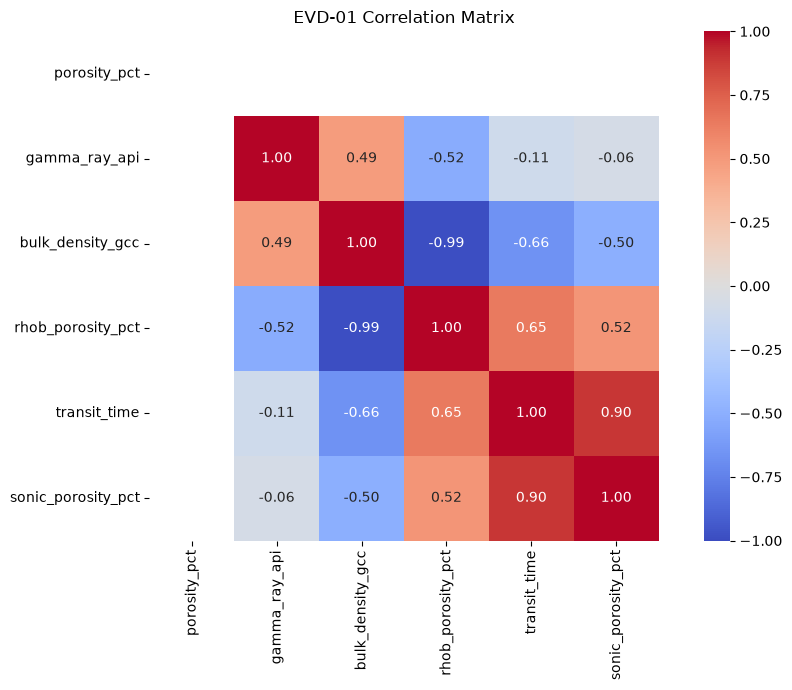

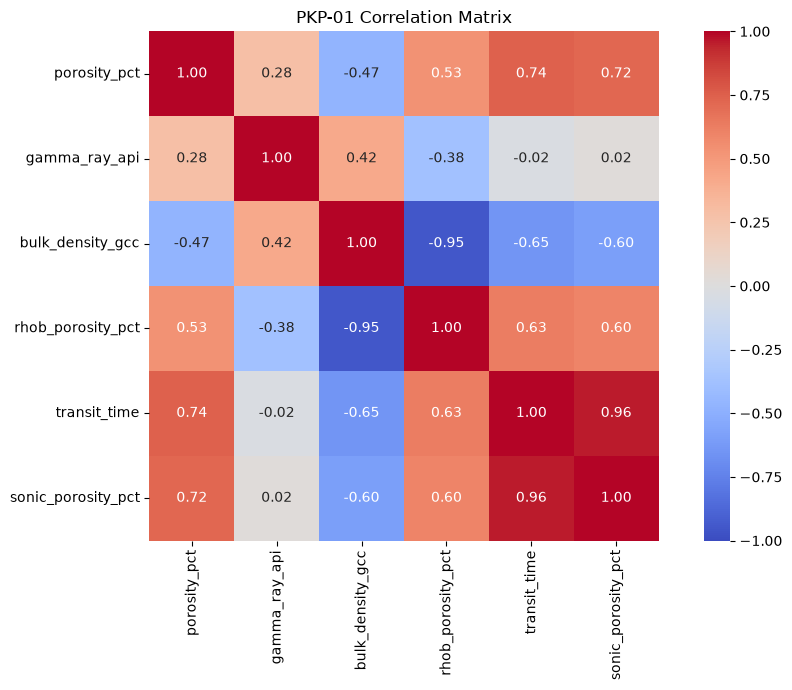

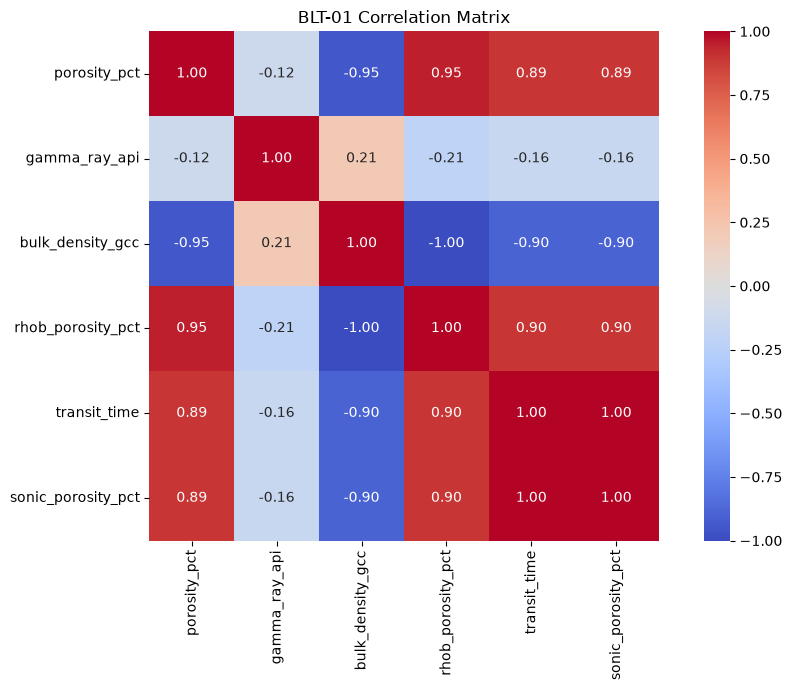

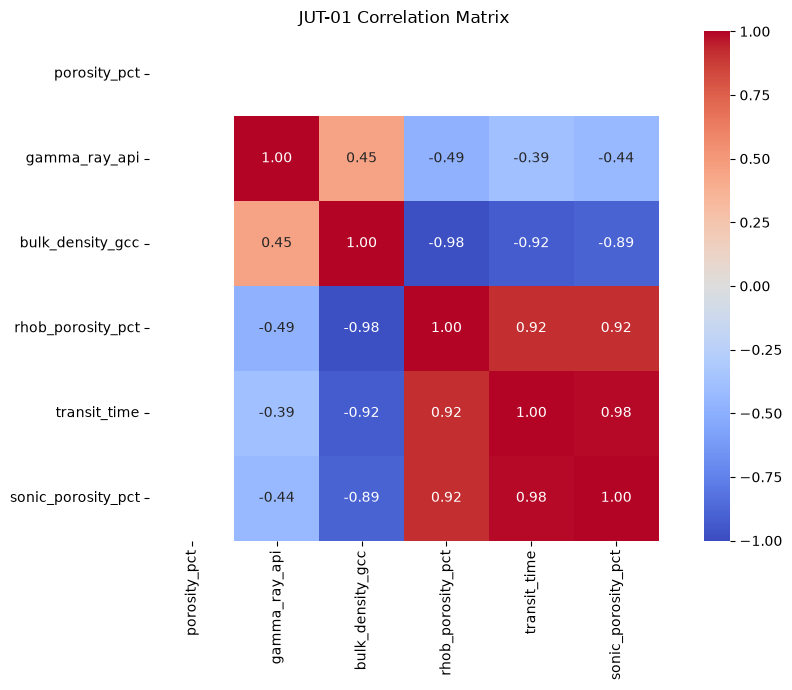

In [20]:
# Correlation heatmaps
for well in well_list:
    tot_cols = log_cols + ["rhob_porosity_pct"] + ["transit_time"] + ["sonic_porosity_pct"]

    corr = df[df["well_id"] == well][tot_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', ax=ax, cmap='coolwarm', vmin=-1, vmax=1, square=True)
    ax.set_title(f'{well} Correlation Matrix')

    plt.tight_layout()

### Using the Porosity-Density Equation:---

=== Model Performance on Test Set ===
  R-squared (R2) : 0.8299
  RMSE           : 1.7789  (Porosity units: percentage)
Well PKP-01 correlation coefficient: 0.534
Well BLT-01 correlation coefficient: 0.952


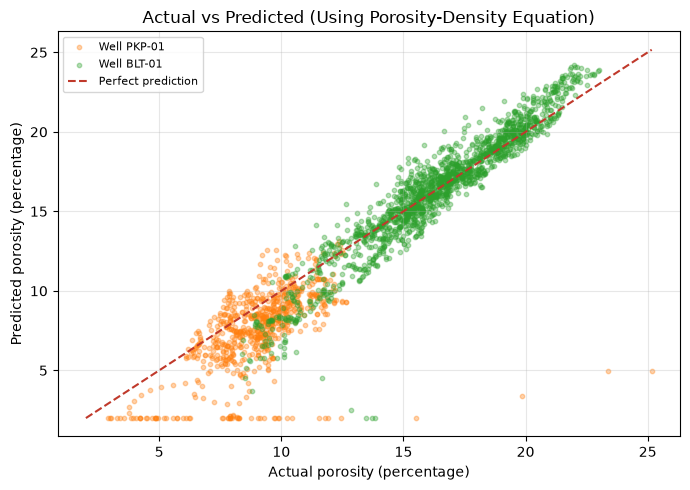

In [21]:
model_df = df[["porosity_pct", "rhob_porosity_pct"]].dropna()
por_true = model_df["porosity_pct"]
por_pred = model_df["rhob_porosity_pct"]

pp_r2   = r2_score(por_true, por_pred)
pp_mse  = mean_squared_error(por_true, por_pred)
pp_rmse = np.sqrt(pp_mse)

print("=== Model Performance on Test Set ===")
print(f"  R-squared (R2) : {pp_r2:.4f}")
print(f"  RMSE           : {pp_rmse:.4f}  (Porosity units: percentage)")

# Step 6: Plot Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 5))
for i, well_id in enumerate(well_list):
    well_df = df[df["well_id"] == well_id]
    if well_df["porosity_pct"].notna().any() and well_df["rhob_porosity_pct"].notna().any():
        ax.scatter(
            well_df["porosity_pct"],
            well_df["rhob_porosity_pct"],
            alpha=0.35,
            s=10,
            color=colors[i % len(colors)],
            label=f"Well {well_id}"
        )
        corr = well_df["porosity_pct"].corr(well_df["rhob_porosity_pct"])
        print(f"Well {well_id} correlation coefficient: {round(corr, 3)}")
min_val = min(por_true.min(), por_pred.min())
max_val = max(por_true.max(), por_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color="#c0392b", linewidth=1.5, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual porosity (percentage)")
ax.set_ylabel("Predicted porosity (percentage)")
ax.set_title("Actual vs Predicted (Using Porosity-Density Equation)")
ax.legend(fontsize=8) 
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Using the Wyllie time-average equation:-

=== Model Performance on Test Set ===
  R-squared (R2) : 0.6660
  RMSE           : 2.4930  (Porosity units: percentage)

 Assessment: Moderate fit -- there is real signal but also unexplained scatter.
Well PKP-01 correlation coefficient: 0.721
Well BLT-01 correlation coefficient: 0.891


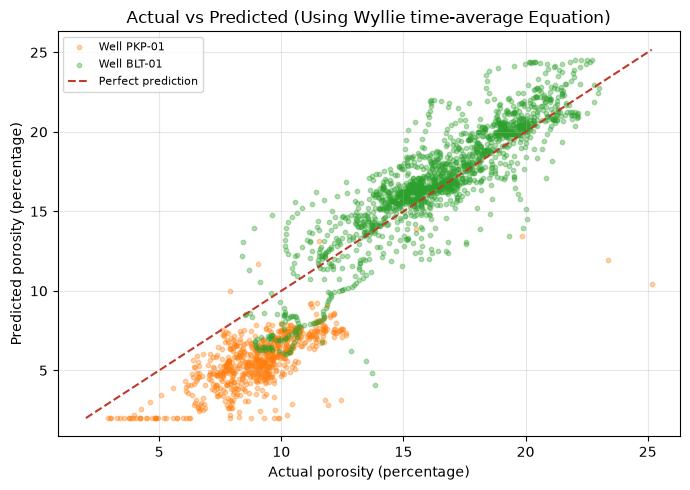

In [22]:
model_df = df[["porosity_pct", "sonic_porosity_pct"]].dropna()
por_true = model_df["porosity_pct"]
por_pred = model_df["sonic_porosity_pct"]

pp_r2   = r2_score(por_true, por_pred)
pp_mse  = mean_squared_error(por_true, por_pred)
pp_rmse = np.sqrt(pp_mse)

print("=== Model Performance on Test Set ===")
print(f"  R-squared (R2) : {pp_r2:.4f}")
print(f"  RMSE           : {pp_rmse:.4f}  (Porosity units: percentage)")

if pp_r2 > 0.7:
    print("\n  Assessment: Good fit -- the model explains most of the variation.")
elif pp_r2 > 0.4:
    print("\n Assessment: Moderate fit -- there is real signal but also unexplained scatter.")
else: 
    print("\n Assessment: Weak fit -- a single feature is not enough to explain porosity variation.")

# Step 6: Plot Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 5))
for i, well_id in enumerate(well_list):
    well_df = df[df["well_id"] == well_id]
    if well_df["porosity_pct"].notna().any() and well_df["sonic_porosity_pct"].notna().any():
        ax.scatter(
            well_df["porosity_pct"],
            well_df["sonic_porosity_pct"],
            alpha=0.35,
            s=10,
            color=colors[i % len(colors)],
            label=f"Well {well_id}"
        )
        corr = well_df["porosity_pct"].corr(well_df["sonic_porosity_pct"])
        print(f"Well {well_id} correlation coefficient: {round(corr, 3)}")
min_val = min(por_true.min(), por_pred.min())
max_val = max(por_true.max(), por_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color="#c0392b", linewidth=1.5, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual porosity (percentage)")
ax.set_ylabel("Predicted porosity (percentage)")
ax.set_title("Actual vs Predicted (Using Wyllie time-average Equation)")
ax.legend(fontsize=8) 
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Feature Selection

In [23]:
FEATURES = ["bulk_density_gcc", "transit_time", "gamma_ray_api"]
TARGET = "porosity_pct"

model_df = df.dropna(subset=FEATURES + [TARGET]).copy()
model_wells = ["BLT-01", "PKP-01"]

### Leave-one-well-out Cross-validation

In [24]:
def make_models():
    return {
        "median_by_well": None,
        "linear_regression": LinearRegression(),
        "random_forest": RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
        "gradient_boosting": XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.03, random_state=42),
    }

In [25]:
def lowo_cv(df, target, wells):
    df = df[df.well_id.isin(wells) & df[target].notna()].reset_index(drop=True)
    
    rows = []

    for test_well in wells:
        train_df = df[df.well_id != test_well]
        test_df = df[df.well_id == test_well]

        if len(train_df) == 0 or len(test_df) == 0:
            continue

        X_train, y_train = train_df[FEATURES], train_df[target]
        X_test, y_test = test_df[FEATURES], test_df[target]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        methods = make_models()

        for name, model in methods.items():
            if name == "median_by_well":
                overall_median = train_df[target].median()
                pred = np.full(shape=len(test_df), fill_value=overall_median)
            else:
                model.fit(X_train_scaled, y_train)
                pred = model.predict(X_test_scaled)
            rows.append({
                "target": target, "method": name, "test_well": test_well,
                "n": len(y_test),
                "MAE": mean_absolute_error(y_test, pred),
                "RMSE": mean_squared_error(y_test, pred) ** 0.5,
                "bias": float(np.mean(pred - y_test)),
                "R2": r2_score(y_test, pred) if len(y_test) > 1 else np.nan,
            })
    
    report = pd.DataFrame(rows)
    
    return report

In [26]:
lowo_cv(model_df, TARGET, model_wells)

,target,method,test_well,n,MAE,RMSE,bias,R2
0,porosity_pct,median_by_well,BLT-01,1689,7.228149,7.805526,-7.221548,-5.942786
1,porosity_pct,linear_regression,BLT-01,1689,1.155289,1.429756,-0.790506,0.767055
2,porosity_pct,random_forest,BLT-01,1689,4.646057,5.314437,-4.588494,-2.218429
3,porosity_pct,gradient_boosting,BLT-01,1689,5.435051,6.091288,-5.402465,-3.228125
4,porosity_pct,median_by_well,PKP-01,730,7.367129,7.569104,7.314207,-14.101653
5,porosity_pct,linear_regression,PKP-01,730,1.346206,1.854949,0.720211,0.093017
6,porosity_pct,random_forest,PKP-01,730,1.976518,2.648673,1.717551,-0.849236
7,porosity_pct,gradient_boosting,PKP-01,730,2.119184,2.617492,1.935034,-0.805953


### JUT-01 & EVD-01 Porosity

In [27]:
train_wells = ["BLT-01", "PKP-01"]
train_df = df[df["well_id"].isin(train_wells)][FEATURES + [TARGET]].dropna()

final_model = LinearRegression()
final_model.fit(train_df[FEATURES], train_df[TARGET])

known_mean_porosity = {'JUT-01': 11.0, 'EVD-01': 9.0}

for well, true_mean in known_mean_porosity.items():
    mask = df["well_id"] == well
    features_for_well = df.loc[mask, FEATURES].dropna()

    raw_pred = final_model.predict(features_for_well)
    offset = true_mean - raw_pred.mean()
    calibrated_pred = raw_pred + offset

    calibrated_pred = np.clip(calibrated_pred, 0.02, None)

    df.loc[features_for_well.index, "porosity_pct"] = calibrated_pred
    df.loc[features_for_well.index, "porosity_source"] = f"linreg_calibrated_to_{true_mean}pct_mean"

    print(f"{well}: raw model mean={raw_pred.mean():.2f}%, offset applied={offset:+.2f}, "
          f"calibrated mean={calibrated_pred.mean():.2f}% (target {true_mean}%)")

JUT-01: raw model mean=10.26%, offset applied=+0.74, calibrated mean=11.04% (target 11.0%)
EVD-01: raw model mean=6.81%, offset applied=+2.19, calibrated mean=9.00% (target 9.0%)


In [28]:
df.groupby("well_id")[["bulk_density_gcc", "gamma_ray_api", "porosity_pct", "rhob_porosity_pct", "sonic_porosity_pct"]].mean()

,bulk_density_gcc,gamma_ray_api,porosity_pct,rhob_porosity_pct,sonic_porosity_pct
well_id,,,,,
BLT-01,2.413076,48.996611,16.376898,16.389297,16.884145
EVD-01,2.514221,28.501493,9.000000,10.519278,3.940622
JUT-01,2.470648,24.318875,11.040885,13.155141,10.204462
PKP-01,2.566157,64.993401,9.041593,7.583406,5.624248


In [29]:
df_filled = df[["well_id", "easting", "northing", "depth_tvd_m", "porosity_pct", "gamma_ray_api", "bulk_density_gcc", "formation_thickness_m"]].copy()
df_filled.info()

<class 'pandas.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                4035 non-null   str    
 1   easting                4035 non-null   float64
 2   northing               4035 non-null   float64
 3   depth_tvd_m            4035 non-null   float64
 4   porosity_pct           4035 non-null   float64
 5   gamma_ray_api          4035 non-null   float64
 6   bulk_density_gcc       4035 non-null   float64
 7   formation_thickness_m  4035 non-null   float64
dtypes: float64(7), str(1)
memory usage: 252.3 KB


In [30]:
df_filled.to_csv(PROCESSED / "target_lithologies_filled.csv", index=False)